In [3]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings('ignore')

# load data
df = pd.read_csv('drive/MyDrive/spotify_merged.csv')
df['stream_window'] = df['stream_window'].apply(ast.literal_eval)
print(f"Loaded {len(df)} songs")

# helper functions
def fit_ar_manual(series, p=1): # manual AR(p) via OLS
    y = np.array(series, dtype=float)
    n = len(y)
    X = np.column_stack([y[p-i-1:n-i-1] for i in range(p)])
    y_target = y[p:]
    return np.linalg.lstsq(X, y_target, rcond=None)[0]

def fit_arma(series): # ARMA(1,1) via statsmodels, fall back to AR(1) if series is degenerate
    try:
        fit = ARIMA(series, order=(1, 0, 1)).fit()
        return fit.arparams[0], fit.maparams[0], fit.resid, fit.aic
    except Exception:
        try:
            fit = ARIMA(series, order=(1, 0, 0)).fit()
            return fit.arparams[0], 0.0, fit.resid, fit.aic
        except Exception:
            return 0.0, 0.0, np.zeros(len(series)), np.nan

# feature extraction
def extract_features(row):
    series = np.array(row['stream_window'], dtype=float)
    if len(series) < 10:
        return None
    diff = np.diff(series)
    ar_coef, ma_coef, resid, aic = fit_arma(diff)
    ar_manual = fit_ar_manual(diff, p=1)
    return {
        'title': row['title'],
        'artist': row['artist'],
        'top10': row['top10'],
        'peak_rank': row['peak_rank'],
        'ar1_coef': ar_coef,
        'ma1_coef': ma_coef,
        'ar1_manual': ar_manual[0] if len(ar_manual) > 0 else 0.0,
        'model_aic': aic,
        'mean_streams': np.mean(series),
        'std_streams': np.std(series),
        'trend_slope': np.polyfit(np.arange(len(series)), series, 1)[0],
        'peak_day': int(np.argmax(series)),
        'volatility': np.std(diff),
        'early_late_ratio': (np.mean(series[:7]) / np.mean(series[14:21])
                             if len(series) >= 21 and np.mean(series[14:21]) > 0 else 1.0),
        'danceability': row['danceability'],
        'energy': row['energy'],
        'valence': row['valence'],
        'tempo': row['tempo'],
        'acousticness': row['acousticness'],
        'loudness': row['loudness'],
        'speechiness': row['speechiness'],
    }


Loaded 3499 songs


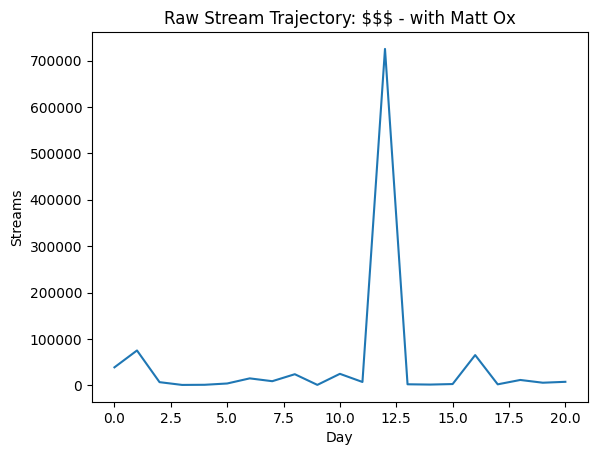

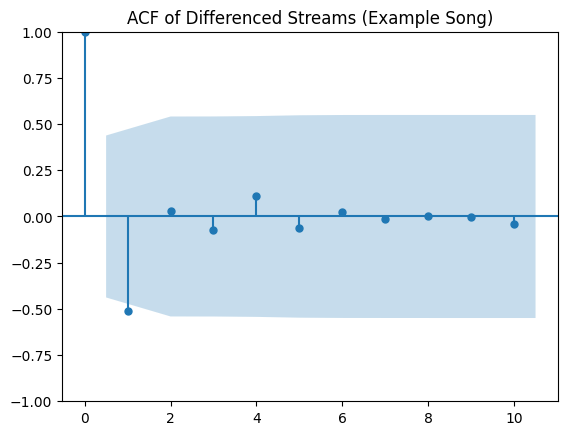

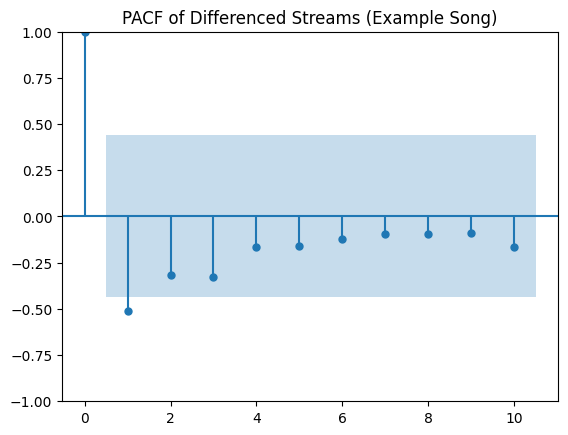

0.03 (Top 10) — MAE: 836, RMSE: 1120


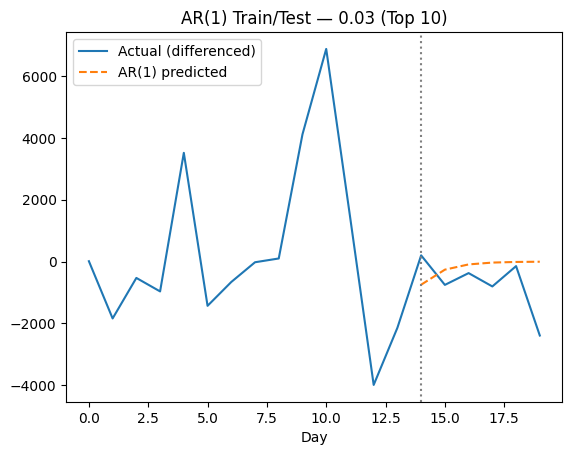

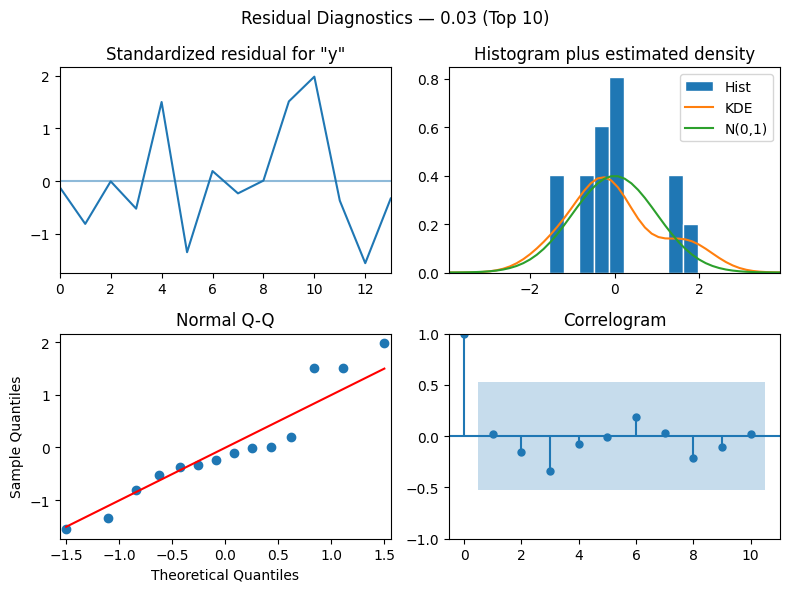

$$$ - with Matt Ox (Non Top 10) — MAE: 23979, RMSE: 36583


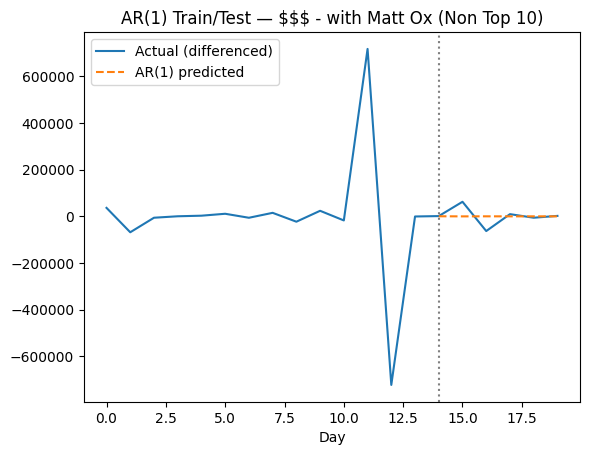

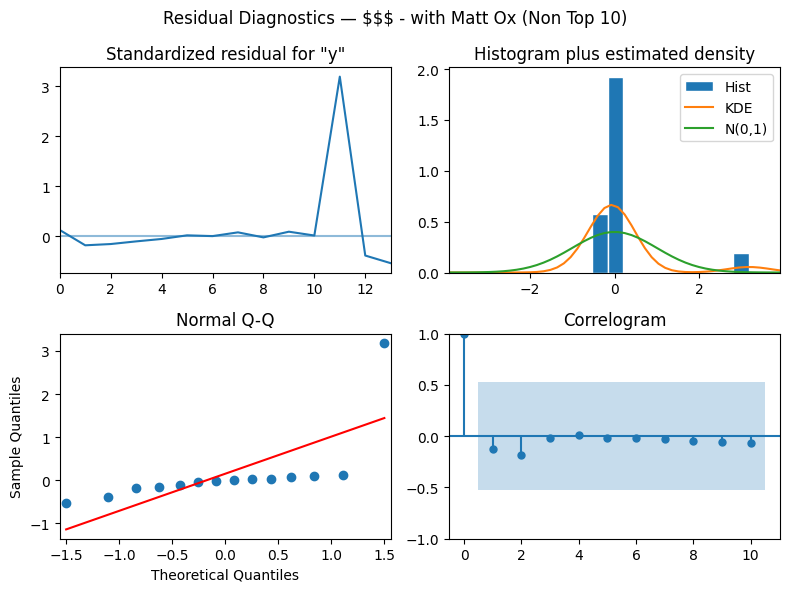

In [11]:
#plots

# sample trajectory
sample     = np.array(df.iloc[0]['stream_window'], dtype=float)
diff_sample = np.diff(sample)

plt.plot(sample)
plt.title(f"Raw Stream Trajectory: {df.iloc[0]['title']}")
plt.xlabel('Day'); plt.ylabel('Streams')
plt.show()

# ACF / PACF
plot_acf(diff_sample,  title='ACF of Differenced Streams (Example Song)')
plt.show()
plot_pacf(diff_sample, title='PACF of Differenced Streams (Example Song)')
plt.show()

# train/test evaluation
def evaluate_song(series_raw, title):
    diff = np.diff(series_raw)
    train, test = diff[:14], diff[14:]
    if len(test) == 0:
        return

    phi = fit_ar_manual(train, p=1)
    preds = []
    start = train[-1]
    for _ in range(len(test)):
        p = float(phi[0] * start)
        preds.append(p)
        start = p

    mae = np.mean(np.abs(np.array(preds) - test))
    rmse = np.sqrt(np.mean((np.array(preds) - test)**2))
    print(f"{title} — MAE: {mae:.0f}, RMSE: {rmse:.0f}")

    plt.plot(range(len(diff)), diff, label='Actual (differenced)')
    plt.plot(range(14, 14 + len(preds)), preds, linestyle='--', label='AR(1) predicted')
    plt.axvline(14, color='gray', linestyle=':')
    plt.title(f"AR(1) Train/Test — {title}")
    plt.legend(); plt.xlabel('Day'); plt.show()

    fit = ARIMA(train, order=(1, 0, 1)).fit()
    fit.plot_diagnostics(figsize=(8, 6))
    plt.suptitle(f"Residual Diagnostics — {title}")
    plt.tight_layout(); plt.show()

hit  = df[df['top10'] == 1].iloc[0]
miss = df[df['top10'] == 0].iloc[0]
evaluate_song(np.array(hit['stream_window'],  dtype=float), f"{hit['title']} (Top 10)")
evaluate_song(np.array(miss['stream_window'], dtype=float), f"{miss['title']} (Non Top 10)")

In [12]:
# extractions & csv saves

print("Extracting features for all songs...")
rows = [extract_features(row) for _, row in df.iterrows()]
features_df = pd.DataFrame([r for r in rows if r is not None])

print(f"Done: {len(features_df)} songs")
print(features_df[['ar1_coef', 'ma1_coef', 'mean_streams', 'trend_slope']].describe().round(3))
print(f"\nTop10 distribution:\n{features_df['top10'].value_counts()}")

features_df.to_csv('arma_features.csv', index=False)
print("\nSaved: arma_features.csv")


Extracting features for all songs...
Done: 3253 songs
       ar1_coef  ma1_coef  mean_streams  trend_slope
count  3253.000  3253.000      3253.000     3253.000
mean     -0.074    -0.611     43008.023      134.117
std       0.433     0.635     58574.809     4310.262
min      -1.000    -1.000      1045.000   -97417.227
25%      -0.348    -0.999      8401.429     -452.257
50%      -0.064    -0.936     25159.714       27.597
75%       0.185    -0.561     54057.143      604.591
max       1.000     1.000    915561.667    55308.014

Top10 distribution:
top10
0    2374
1     879
Name: count, dtype: int64

Saved: arma_features.csv
